Importation des bibliothèque

In [3]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt 
from biopandas.pdb import PandasPdb
import nglview as nv
from scipy import stats

In [2]:
def view_structure(file_pdb):
    # 1. Charger le fichier généré
    view = nv.show_file(file_pdb)
    # 2. Vider les représentations par défaut
    view.clear_representations()
    # 3. Afficher toute la molécule de manière fine
    view.add_representation('licorice', selection='all', color='element')
    # 4. Mettre en surbrillance spéciale les atomes de Phosphore (les "noeuds" des liaisons phosphodiester)
    view.add_representation('spacefill', selection='_P', color='orange', radius=0.8)
    # 5. Rajouter un "tube" qui suit et met en évidence de façon continue le squelette phosphodiester (backbone)
    view.add_representation('tube', selection='backbone', color='red', radius=0.2)
    
    # # 6. Ajout d'un dégradé de couleur pour voir l'orientation 5' -> 3'
    # # Le schéma 'resindex' colore du bleu (début/5') au rouge (fin/3')
    # view.add_representation('cartoon', selection='nucleic', color='resindex')
    
    # 7. Centrer la vue
    view.center()
    # Afficher l'interface
    return view

In [4]:
view_structure("resultat/optimized_bs_rasp_1776157147_full_atom.pdb")

NGLWidget()

In [5]:
view_structure("resultat/optimized_bs_dfire_1776157204_full_atom.pdb")

NGLWidget()

In [9]:
view_structure("resultat/optimized_bs_rsRNASP_1776159199_full_atom.pdb")

NGLWidget()

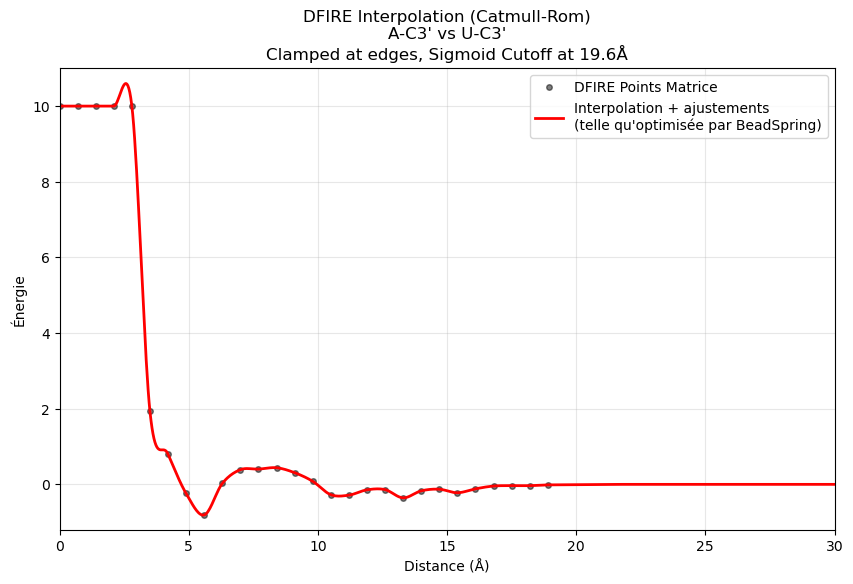

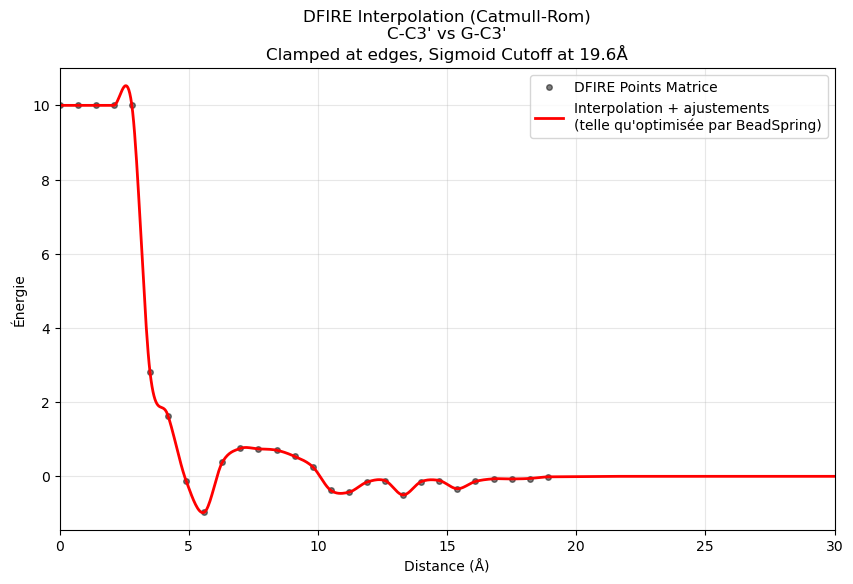

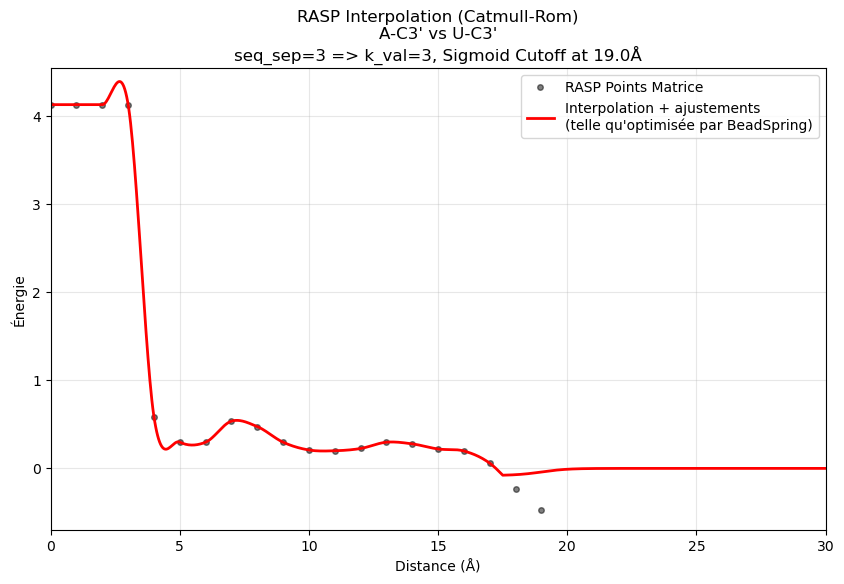

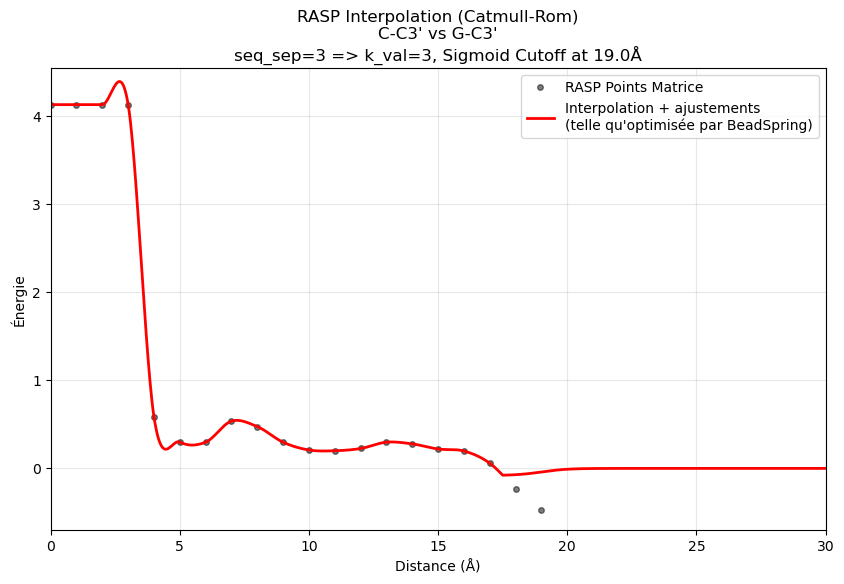

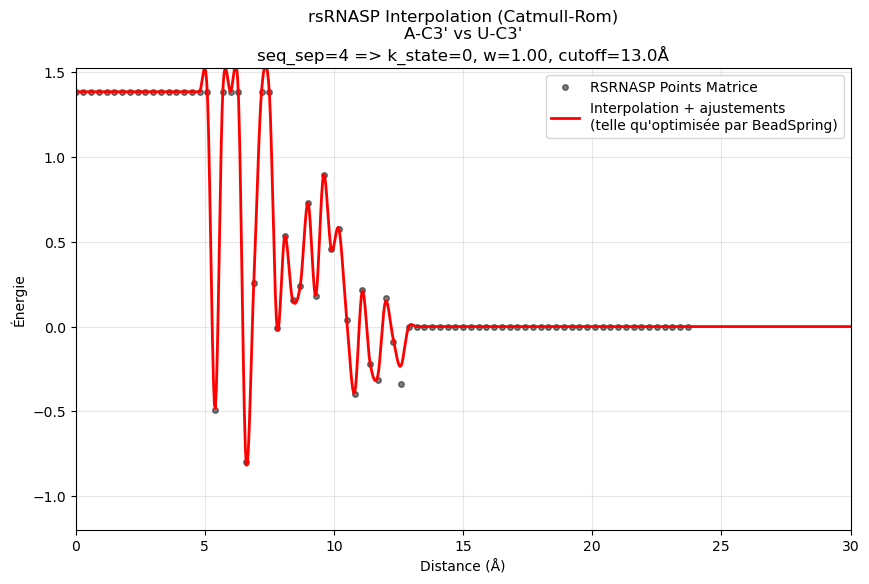

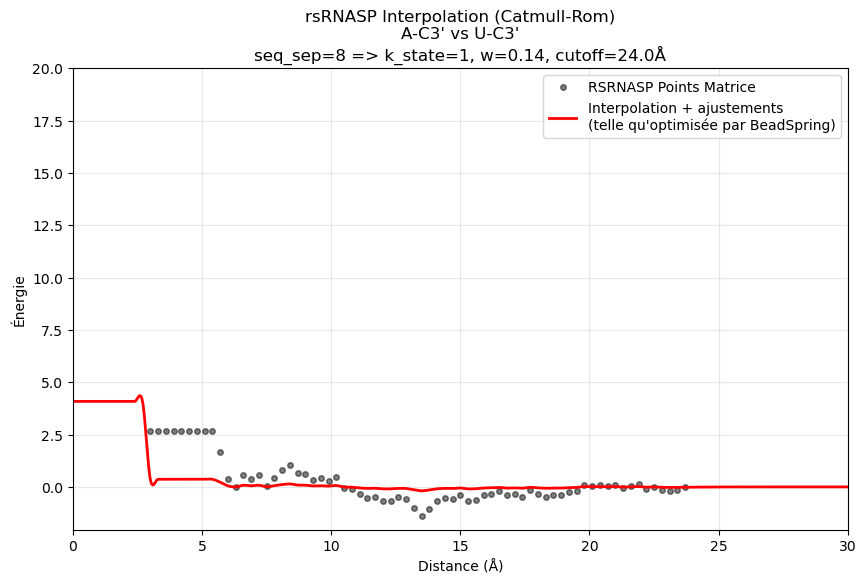

In [3]:
from fonction import plot_interpolation_dist
import matplotlib.pyplot as plt

# Affiche la courbe d'interpolation DFIRE pour la paire d'atomes G(C3') vs U(P)
plot_interpolation_dist(
    score_type="dfire", 
    res1="A", atom1="C3'", 
    res2="U", atom2="C3'"
)

plot_interpolation_dist(
    score_type="dfire", 
    res1="C", atom1="C3'", 
    res2="G", atom2="C3'"
)

# Test avec une petite distance (seq_sep = 3)
plot_interpolation_dist(
    score_type="rasp", 
    res1="A", atom1="C3'", 
    res2="U", atom2="C3'", 
    seq_sep=3
)

plot_interpolation_dist(
    score_type="rasp", 
    res1="C", atom1="C3'", 
    res2="G", atom2="C3'", 
    seq_sep=3
)

# --- Interaction à courte portée (Short-range) ---
# k_state sera défini à 0, le Cutoff s'amorce à 13.0 Å et le poids est de 1.0
plot_interpolation_dist(
    score_type="rsrnasp", 
    res1="A", atom1="C3'", 
    res2="U", atom2="C3'", 
    seq_sep=4  # <= 4 déclenche la fonction short-ranged
)

# --- Interaction à longue portée (Long-range) ---
# k_state = 1, le Cutoff est prolongé jusqu'à 24.0 Å
# Le poids topologique "w_long" variera en fonction de num_beads (= taille ARN)
plot_interpolation_dist(
    score_type="rsrnasp", 
    res1="A", atom1="C3'", 
    res2="U", atom2="C3'", 
    seq_sep=8,       # >= 5 déclenche la fonction long-ranged
    num_beads=24    # Indique un ARN total de 100 nucléotides pour le calcul du poids
)

